In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('D:/bishe_zoujun/test1/data_all/Data for repository.csv')
df.head()


,Movie_Name,Release_Period,Whether_Remake,Whether_Franchise,Genre,New_Actor,New_Director,New_Music_Director,Lead_Star,Director,Music_Director,Number_of_Screens,Revenue(INR),Budget(INR)
0,Golden Boys,Normal,No,No,suspense,Yes,No,No,Jeet Goswami,Ravi Varma,Baba Jagirdar,5,5000000,85000
1,Kaccha Limboo,Holiday,No,No,drama,Yes,No,Yes,Karan Bhanushali,Sagar Ballary,Amardeep Nijjer,75,15000000,825000
2,Not A Love Story,Holiday,No,No,thriller,No,No,No,Mahie Gill,Ram Gopal Verma,Sandeep Chowta,525,75000000,56700000
3,Qaidi Band,Holiday,No,No,drama,Yes,No,No,Aadar Jain,Habib Faisal,Amit Trivedi,800,210000000,4500000
4,Chaatwali,Holiday,No,No,adult,Yes,Yes,Yes,Aadil Khan,Aadil Khan,Babloo Ustad,1,1000000,1075000


In [3]:
df['Revenue(INR)'] = df['Revenue(INR)'] / 83.5
df['Budget(INR)'] = df['Budget(INR)'] / 83.5


In [4]:
df.rename(columns={'Revenue(INR)': 'gross'}, inplace=True)
df.rename(columns={'Budget(INR)': 'budget'}, inplace=True)
df.rename(columns={'Genre': 'genres'}, inplace=True)

In [5]:
df.head()

,Movie_Name,Release_Period,Whether_Remake,Whether_Franchise,genres,New_Actor,New_Director,New_Music_Director,Lead_Star,Director,Music_Director,Number_of_Screens,gross,budget
0,Golden Boys,Normal,No,No,suspense,Yes,No,No,Jeet Goswami,Ravi Varma,Baba Jagirdar,5,5.988024e+04,1017.964072
1,Kaccha Limboo,Holiday,No,No,drama,Yes,No,Yes,Karan Bhanushali,Sagar Ballary,Amardeep Nijjer,75,1.796407e+05,9880.239521
2,Not A Love Story,Holiday,No,No,thriller,No,No,No,Mahie Gill,Ram Gopal Verma,Sandeep Chowta,525,8.982036e+05,679041.916168
3,Qaidi Band,Holiday,No,No,drama,Yes,No,No,Aadar Jain,Habib Faisal,Amit Trivedi,800,2.514970e+06,53892.215569
4,Chaatwali,Holiday,No,No,adult,Yes,Yes,Yes,Aadil Khan,Aadil Khan,Babloo Ustad,1,1.197605e+04,12874.251497


In [6]:

import numpy as np
import lightgbm as lgb       # LightGBM模型
from sklearn.model_selection import train_test_split  # 划分训练集/测试集
from sklearn.preprocessing import LabelEncoder        # 类别特征编码
from sklearn.metrics import mean_squared_error, r2_score  # 模型评估指标
import matplotlib.pyplot as plt  # 绘图库
import joblib

In [7]:
X = df[['genres','New_Director','New_Actor','budget']]
y = df['gross']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)#不设置random_state，每次运行结果不同

In [8]:
# 找出类别列
cat_cols = X_train.select_dtypes(include=['object']).columns
# 对类别特征编码
le = LabelEncoder()
for col in cat_cols:
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col] = le.transform(X_test[col])

In [9]:
# 创建数据集
train_data = lgb.Dataset(X_train, label=y_train)
test_data = lgb.Dataset(X_test, label=y_test, reference=train_data)
#reference=train_data 验证集与训练集保持相同特征结构，确保评估指标计算正确。

# 设置参数
params = {
    'objective': 'regression',  # 任务类型： regression （回归）、 binary （二分类）、 multiclass （多分类
    'metric': 'rmse',  #评估指标： rmse （均方根误差）、 mae （平均绝对误差）、 auc （分类用）
    'boosting_type': 'gbdt',  #提升算法： gbdt （传统梯度提升）、 dart （带dropout）、 goss （基于梯度采样）
    'num_leaves': 31,  #单棵树最大叶子节点数，控制模型复杂度，越大越容易过拟合
    'learning_rate': 0.05  #每棵树对最终结果的贡献权重，越小收敛越慢但更稳定，通常配合更多树使用
}

# 训练模型
model = lgb.train(
    params, 
    train_data, 
    num_boost_round=100,
    valid_sets=[train_data, test_data], #监控验证集上的指标，防止过拟合
    valid_names=['train', 'valid']  #验证集名称，用于在训练过程中显示指标
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000039 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 271
[LightGBM] [Info] Number of data points in the train set: 1358, number of used features: 4
[LightGBM] [Info] Start training from score 1804427.724550


In [10]:
#测试并计算RMSE（均方根误差）和R²指标
y_pred = model.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")

y_train_pred = model.predict(X_train)
train_r2 = r2_score(y_train, y_train_pred)
print(f"训练集 R²: {train_r2:.4f}")
print(f"测试集 R²: {r2:.4f}")

RMSE: 1442791.27
训练集 R²: 0.8274
测试集 R²: 0.7623


[ 678  202   68 2052]


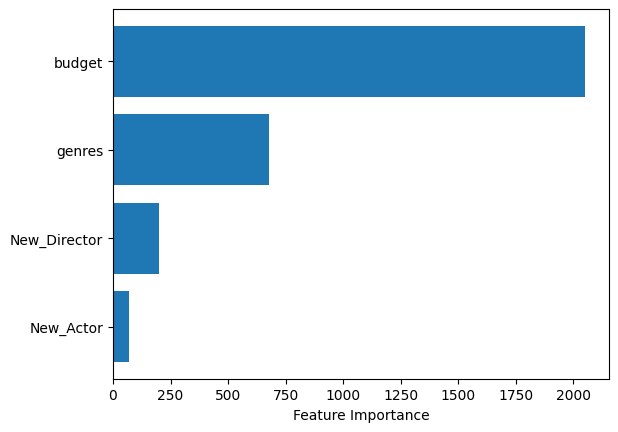

In [11]:
importance = model.feature_importance() # 特征重要性
print(importance)
feature_names = X_train.columns  
sorted_idx = importance.argsort() # 按重要性排序

# 绘制特征重要性条形图
plt.barh(range(len(sorted_idx)), importance[sorted_idx])
plt.yticks(range(len(sorted_idx)), feature_names[sorted_idx])
plt.xlabel("Feature Importance")
plt.show()

In [12]:
# 保存模型
joblib.dump(model, 'lightgbm_model_1.pkl')
joblib.dump(le, 'label_encoder_1.pkl')

['label_encoder_1.pkl']